<a href="https://colab.research.google.com/github/ayrhoden3/VSCODE-Projects/blob/main/Wnba_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Python Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from zipfile import ZipFile
import os
from IPython.display import display, HTML
import plotly.express as px

Import Datafile

In [ ]:
!wget -O wnba_team_box_score https://www.dropbox.com/scl/fi/wgz5ns7ormtwzgmzfqfmr/wnba_team_box_score_22.xlsx?rlkey=wocgxla2861qlg9zb561jetec&e=1&dl=0

--2025-10-14 21:33:55--  https://www.dropbox.com/scl/fi/wgz5ns7ormtwzgmzfqfmr/wnba_team_box_score_22.xlsx?rlkey=wocgxla2861qlg9zb561jetec
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc8393da530515d1e6383ca7c74e.dl.dropboxusercontent.com/cd/0/inline/CzPqQPd5xY_UdESTvrugQtzP8Y0JPn92vJXwlQFaMdPxVNIse2cW28Gl-UqtSByT7ea1gKcG3JLNRzy-esvs6ZymqstqzlnSzPdryvuPE-hQOapj7umGSdGZBE6bVV2IGlw/file# [following]
--2025-10-14 21:33:55--  https://uc8393da530515d1e6383ca7c74e.dl.dropboxusercontent.com/cd/0/inline/CzPqQPd5xY_UdESTvrugQtzP8Y0JPn92vJXwlQFaMdPxVNIse2cW28Gl-UqtSByT7ea1gKcG3JLNRzy-esvs6ZymqstqzlnSzPdryvuPE-hQOapj7umGSdGZBE6bVV2IGlw/file
Resolving uc8393da530515d1e6383ca7c74e.dl.dropboxusercontent.com (uc8393da530515d1e6383ca7c74e.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:601d:15::a27d:50f
Connec

In [ ]:
wnba_box_score_df = pd.read_excel('wnba_team_box_score')

In [ ]:
wnba_box_score_df.shape

(432, 31)

In [ ]:
fever_df = wnba_box_score_df[wnba_box_score_df['TEAM'] == 'Indiana Fever'].copy()

# Create a column “LOCATION”: “Home” or “Away”
def get_location(row):
    if row['HOME_TEAM_ID'] == 158:
        return 'Home'
    else:
        return 'Away'

fever_df['LOCATION'] = fever_df.apply(get_location, axis=1)

# Pivot so that Home and Away are columns
fever_home_away_avg = fever_df.pivot_table(
    values=["POINTS", "TOTAL_REBOUNDS"],
    index="TEAM",
    columns="LOCATION",
    aggfunc="mean"
)

fever_home_away_avg.columns = [f"{stat}_{loc}" for stat, loc in fever_home_away_avg.columns]

fever_home_away_avg["POINTS_ALL"] = fever_df.groupby("TEAM")["POINTS"].mean()
fever_home_away_avg["REBOUNDS_ALL"] = fever_df.groupby("TEAM")["TOTAL_REBOUNDS"].mean()

fever_home_away_avg["POINTS_Diff"] = fever_home_away_avg["POINTS_Home"] - fever_home_away_avg["POINTS_Away"]
fever_home_away_avg["REBOUNDS_Diff"] = fever_home_away_avg["TOTAL_REBOUNDS_Home"] - fever_home_away_avg["TOTAL_REBOUNDS_Away"]

fever_home_away_avg

,POINTS_Away,POINTS_Home,TOTAL_REBOUNDS_Away,TOTAL_REBOUNDS_Home,POINTS_ALL,REBOUNDS_ALL,POINTS_Diff,REBOUNDS_Diff
TEAM,,,,,,,,
Indiana Fever,76.666667,79.277778,34.166667,32.333333,77.972222,33.25,2.611111,-1.833333


Question 1:
The Indiana Fever's home and away splits for points and rebounds are pretty much the same. Only scoring on avg 3 more points at home than away. Shockingly though, they seem to rebound slightly better on the road, which is unusual for most teams.

In [ ]:
# Estimate number of possesions per team per game
wnba_box_score_df['EST_Poss'] = 0.96 * (
    wnba_box_score_df["FIELD_GOALS_ATT"] +
    wnba_box_score_df["TURNOVERS"] +
    0.44 * wnba_box_score_df["FREE_THROWS_ATT"] -
    wnba_box_score_df["OFFENSIVE_REBOUNDS"]
)

# Estimate the rating per game
wnba_box_score_df['Eff_Rating'] = 100 * (wnba_box_score_df["POINTS"] / wnba_box_score_df["EST_Poss"])


In [ ]:
# let's get the TEAM and TEAM_ID list first
teams = (
    wnba_box_score_df[["TEAM", "TEAM_ID"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(teams)


                  TEAM  TEAM_ID
0        Seattle Storm      161
1      Connecticut Sun      157
2        Indiana Fever      158
3     New York Liberty      150
4          Chicago Sky     5691
5       Minnesota Lynx      156
6   Washington Mystics      154
7      Phoenix Mercury      151
8   Los Angeles Sparks      149
9        Atlanta Dream     8406
10      Las Vegas Aces      153
11        Dallas Wings      155


In [ ]:
# now let's add the column with OPP_TEAM

# 1. Compute opponent ID (vectorized)
wnba_box_score_df["__opp_id"] = np.where(
    wnba_box_score_df["TEAM_ID"] == wnba_box_score_df["HOME_TEAM_ID"], wnba_box_score_df["AWAY_TEAM_ID"], wnba_box_score_df["HOME_TEAM_ID"]
)

# 2. Merge with existing teams DataFrame, but only bring in the name
wnba_box_score_df = wnba_box_score_df.merge(
    teams.rename(columns={"TEAM_ID": "__opp_id", "TEAM": "OPP_TEAM"}),
    on="__opp_id",
    how="left"
)

# 3. Drop the temporary ID
wnba_box_score_df = wnba_box_score_df.drop(columns="__opp_id")

wnba_box_score_df[["TEAM", "TEAM_ID", "OPP_TEAM"]]


,TEAM,TEAM_ID,OPP_TEAM
0,Seattle Storm,161,Connecticut Sun
1,Connecticut Sun,157,Seattle Storm
2,Indiana Fever,158,Chicago Sky
3,New York Liberty,150,Minnesota Lynx
4,Seattle Storm,161,New York Liberty
...,...,...,...
427,Los Angeles Sparks,149,Las Vegas Aces
428,Dallas Wings,155,Chicago Sky
429,Atlanta Dream,8406,Dallas Wings
430,Las Vegas Aces,153,Atlanta Dream


Indiana Fever Defensive ratings

In [ ]:
# Create a column “LOCATION” from each team's perspective: “Home” or “Away”
def get_location(row):
    if row['TEAM_ID'] == row['HOME_TEAM_ID']:
        return 'Home'
    else:
        return 'Away'

wnba_box_score_df['LOCATION'] = wnba_box_score_df.apply(get_location, axis=1)

def_overall_off_rating = wnba_box_score_df[wnba_box_score_df["OPP_TEAM"] == "Indiana Fever"]['Eff_Rating'].mean()

def_home_off_rating = wnba_box_score_df[(wnba_box_score_df["OPP_TEAM"] == "Indiana Fever") & (wnba_box_score_df["LOCATION"] == "Home")]['Eff_Rating'].mean()

def_away_off_rating = wnba_box_score_df[(wnba_box_score_df["OPP_TEAM"] == "Indiana Fever") & (wnba_box_score_df["LOCATION"] == "Away")]['Eff_Rating'].mean()

print("Overall Rating: ", def_overall_off_rating)
print("Home Rating: ", def_home_off_rating)
print("Away Rating: ", def_away_off_rating)

Overall Rating:  111.66354666045335
Home Rating:  109.67846233675701
Away Rating:  113.64863098414968


Indiana Fever Offensive team ratings

In [ ]:
# Create a column “LOCATION” from each team's perspective: “Home” or “Away”
def get_location(row):
    if row['TEAM_ID'] == row['HOME_TEAM_ID']:
        return 'Home'
    else:
        return 'Away'

wnba_box_score_df['LOCATION'] = wnba_box_score_df.apply(get_location, axis=1)


overall_off_rating = wnba_box_score_df[wnba_box_score_df["TEAM"] == "Indiana Fever"]['Eff_Rating'].mean()

home_off_rating = wnba_box_score_df[(wnba_box_score_df["TEAM"] == "Indiana Fever") & (wnba_box_score_df["LOCATION"] == "Home")]['Eff_Rating'].mean()

away_off_rating = wnba_box_score_df[(wnba_box_score_df["TEAM"] == "Indiana Fever") & (wnba_box_score_df["LOCATION"] == "Away")]['Eff_Rating'].mean()

print("Overall Rating: ", overall_off_rating)
print("Home Rating: ", home_off_rating)
print("Away Rating: ", away_off_rating)

Overall Rating:  97.63283779150032
Home Rating:  98.98288735937994
Away Rating:  96.28278822362073


Question 2:
The Indiana Fever perform slightly better offensively at home compared to away games. However, their defense is significantly weaker, especially on the road, where they allow an average rating of 113.65 compared to 109.68 at home.

In [ ]:
!wget -O wnba_pbp_data_2022.csv https://www.dropbox.com/scl/fi/o4ac4t31cb8ixi1yn3ok3/wnba_pbp_data_2022.csv?rlkey=geuh1cqghdvrgnfcxldhi5y64&dl=0
!wget -O wnba_player_game_data.csv https://www.dropbox.com/scl/fi/41bdhhtujgx0yz1lls9w1/wnba_player_game_data.csv?rlkey=e7i0mrqwcz6s2mw6qhd80nycq&dl=0

--2025-10-14 21:33:58--  https://www.dropbox.com/scl/fi/o4ac4t31cb8ixi1yn3ok3/wnba_pbp_data_2022.csv?rlkey=geuh1cqghdvrgnfcxldhi5y64
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc00d88fc66892aacab534151524.dl.dropboxusercontent.com/cd/0/inline/CzMUYnvmHBpPmbhGOd_qbRDaAFQLqCNItzc7NII1He-r8A_NmBuDWE6yHtlRyrCgq2shflvEnf-jXDMjxOJWN-ZcoYz-QbF2a5AtPBBgJfhDFLZAZ28NmGi3ZFRHMnppiyY/file# [following]
--2025-10-14 21:33:59--  https://uc00d88fc66892aacab534151524.dl.dropboxusercontent.com/cd/0/inline/CzMUYnvmHBpPmbhGOd_qbRDaAFQLqCNItzc7NII1He-r8A_NmBuDWE6yHtlRyrCgq2shflvEnf-jXDMjxOJWN-ZcoYz-QbF2a5AtPBBgJfhDFLZAZ28NmGi3ZFRHMnppiyY/file
Resolving uc00d88fc66892aacab534151524.dl.dropboxusercontent.com (uc00d88fc66892aacab534151524.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:601d:15::a27d:50f
Connecting 

In [ ]:
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = plt.gca()

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        # Draw the half court line, baseline and side out bound lines
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

In [ ]:
# Load in the data files and do some more pre-processing
inputDF = pd.read_csv('wnba_pbp_data_2022.csv')
player_info_df = pd.read_csv('wnba_player_game_data.csv')

# get the shot distance and create the shot dataframe.
# get the shotDF - need the distance not to have a nan
shotDF = inputDF[inputDF['X_SHOT_COORDINATE'].notna()]
l2_distances = np.linalg.norm(shotDF[['X_SHOT_COORDINATE', 'Y_SHOT_COORDINATE']].values, axis=1)

# Add the calculated distances to the DataFrame
shotDF['L2_distance'] = l2_distances

# get the shots made and missed based on distance
shotDF_made = shotDF[shotDF['EVENT_DESC'] == 'Field Goal Made']
shotDF_missed = shotDF[shotDF['EVENT_DESC'] == 'Field Goal Missed']

/tmp/ipython-input-1801029718.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shotDF['L2_distance'] = l2_distances


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# --- Indiana Fever team ID ---
TEAM_ID = 158

# get the player_list (player IDs from the shot chart data)
player_list = np.unique(
    inputDF[inputDF['OFF_TEAM_ID'] == TEAM_ID]['OFFENSIVE_PLAYER'].dropna().astype(int).to_list()
)

# create a player_dataframe matched by numeric PLAYER_ID
filtered_player_df = player_info_df[player_info_df['PLAYER_ID'].astype(int).isin(player_list)]

# Create a list of (name, id) tuples for the widget
player_info_list = []
for index, row in filtered_player_df.iterrows():
    player_name_tuple = (row['PLAYER'], int(row['PLAYER_ID']))
    player_info_list.append(player_name_tuple)


def plot_player_made_missed_map(player_select, shotDF):
    # handle widget returning a tuple (name, id)
    if isinstance(player_select, (tuple, list)):
        player_name = player_select[0]
        player_id = int(player_select[1])
    else:
        # try numeric first
        try:
            player_id = int(player_select)
            player_name = player_info_df.loc[player_info_df['PLAYER_ID'].astype(int) == player_id, 'PLAYER'].iat[0]
        except Exception:
            player_name = player_select
            player_id = int(player_info_df.loc[player_info_df['PLAYER'] == player_name, 'PLAYER_ID'].iat[0])

    # filter by numeric player_id and Indiana Fever team
    playerShotDF = shotDF[
        (shotDF['OFFENSIVE_PLAYER'].astype(int) == player_id) &
        (shotDF['OFF_TEAM_ID'] == TEAM_ID)
    ]
    playerShotDF_made = playerShotDF[playerShotDF['EVENT_DESC'] == 'Field Goal Made']
    playerShotDF_missed = playerShotDF[playerShotDF['EVENT_DESC'] == 'Field Goal Missed']

    print(f"{player_name} (ID: {player_id}) — shots: {playerShotDF.shape[0]}")

    plt.figure(figsize=(6,6))
    plt.plot(playerShotDF_missed['X_SHOT_COORDINATE']*10, playerShotDF_missed['Y_SHOT_COORDINATE']*10, 'rx', markersize=2)
    plt.plot(playerShotDF_made['X_SHOT_COORDINATE']*10, playerShotDF_made['Y_SHOT_COORDINATE']*10, 'go', markersize=2)

    draw_court(outer_lines=True)
    plt.xlim(300, -300)
    plt.ylim(-100, 500)
    plt.title(f"{player_name} - Made (green) / Missed (red)")
    plt.show()
    return()


@interact(player_select=player_info_list)
def g(player_select):
    print(player_select)
    plot_player_made_missed_map(player_select, shotDF)


interactive(children=(Dropdown(description='player_select', options=(('Emma Cannon', 411640), ('Danielle Robin…

In [ ]:
# let's get the TEAM_ID and the TEAM_NAME sorted
unique_teams = player_info_df[["CURR_TEAM_ID", "CURR_TEAM"]].drop_duplicates()

# now add in the CURR_TEAM to the shotDF dataframe
shotDF = shotDF.merge(
    unique_teams,
    how="left",
    left_on="OFF_TEAM_ID",
    right_on="CURR_TEAM_ID"
)

# change the CURR_TEAM to TEAM_NAME
shotDF = shotDF.rename(columns={"CURR_TEAM": "TEAM_NAME"})

# Add in Home and Away Location information
shotDF["LOCATION"] = np.where(shotDF["HOME_TEAM"] == shotDF["CURR_TEAM_ID"], "Home", "Away")

# how many Home shots vs Away shots?
shotDF["LOCATION"].value_counts()
shotDF

KeyError: "None of [Index(['CURR_TEAM_ID', 'CURR_TEAM'], dtype='object')] are in the [columns]"

In [ ]:
from scipy.ndimage import gaussian_filter
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# --- Build the team list ---
team_list = np.unique(shotDF['TEAM_NAME'].to_list())

# --- Define plotting function at the team level ---
def plot_team_made_missed_map(team_select, shotDF, location="All", smoothing=False):
    # filter shots for this team
    teamShotDF = shotDF[shotDF['TEAM_NAME'] == team_select]

    # Optional: filter by Home/Away
    if location == "Home":
        teamShotDF = teamShotDF[teamShotDF["LOCATION"] == "Home"]
    elif location == "Away":
        teamShotDF = teamShotDF[teamShotDF["LOCATION"] == "Away"]

    # Split made/missed
    teamShotDF_made = teamShotDF[teamShotDF['EVENT_DESC'] == 'Field Goal Made']
    teamShotDF_missed = teamShotDF[teamShotDF['EVENT_DESC'] == 'Field Goal Missed']

    # Histogram bins
    x_edges_input = np.linspace(-260,260,52 )
    y_edges_input = np.linspace(-40, 800, 85)
    cmap = plt.cm.viridis

    hist_data_made, xedges_made, yedges_made = np.histogram2d(
        teamShotDF_made['X_SHOT_COORDINATE'] * 10,
        teamShotDF_made['Y_SHOT_COORDINATE'] * 10,
        bins=[x_edges_input, y_edges_input]
    )

    hist_data_all, xedges_all, yedges_all = np.histogram2d(
        teamShotDF['X_SHOT_COORDINATE'] * 10,
        teamShotDF['Y_SHOT_COORDINATE'] * 10,
        bins=[x_edges_input, y_edges_input]
    )

    # Ratio (made / all)
    norm_all = np.divide(hist_data_made, hist_data_all)
    norm_all_without_nan = np.nan_to_num(norm_all, nan=0.0, posinf=0.0, neginf=0.0)

    # Apply Gaussian smoothing if checked
    if smoothing:
        norm_all_without_nan = gaussian_filter(norm_all_without_nan, sigma=1.5)

    # Plot
    plt.figure(figsize=(6,5))
    draw_court(outer_lines=True)

    plt.imshow(
        norm_all_without_nan.T,
        extent=[xedges_all[0], xedges_all[-1], yedges_all[0], yedges_all[-1]],
        origin='lower', cmap=cmap, vmin=0, vmax=0.6
    )

    plt.colorbar(label='Ratio (Made / Total)')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(f'{team_select} - 2D Shot Efficiency Map')
    plt.xlim(250,-250)
    plt.ylim(0,300)
    plt.show()


# --- Interactive selection ---
@interact(
    team_select=team_list,
    location=["All", "Home", "Away"],
    smoothing=False  # add checkbox for smoothing
)
def g(team_select, location, smoothing):
    plot_team_made_missed_map(team_select, shotDF, location, smoothing)


KeyError: 'TEAM_NAME'

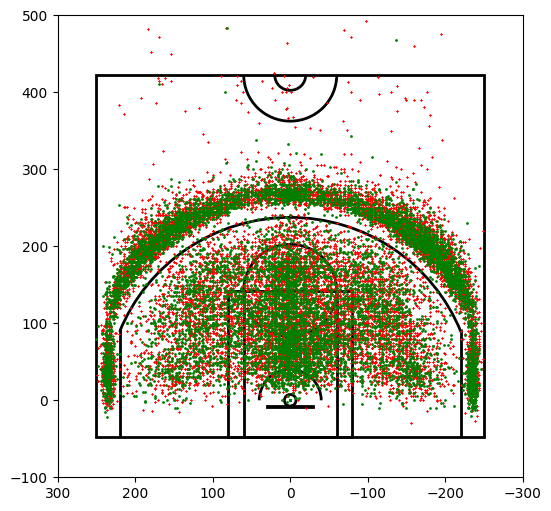

In [ ]:
# @title
### Let's plot the locations of all the shot
plt.figure(figsize=(6,6))
plt.plot(shotDF_missed['X_SHOT_COORDINATE']*10, shotDF_missed['Y_SHOT_COORDINATE']*10,'rx',markersize=1)
plt.plot(shotDF_made['X_SHOT_COORDINATE']*10, shotDF_made['Y_SHOT_COORDINATE']*10,'go', markersize=1)

draw_court(outer_lines=True)
# Descending values along the axis from left to right
plt.xlim(300,-300)
plt.ylim(-100,500)
plt.show()

/tmp/ipython-input-379731313.py:17: RuntimeWarning: invalid value encountered in divide
  norm_all = np.divide(hist_data_made, hist_data_all)


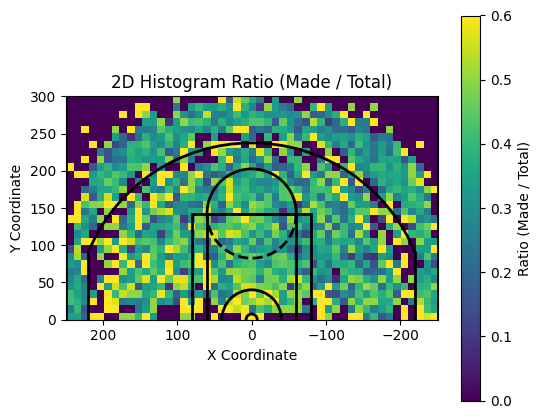

In [ ]:
# need to explicitly set the bins for made and all - they are slightly different
x_edges_input = np.linspace(-260,260,52 )  # Adjust the edges as needed
y_edges_input = np.linspace(-40, 800, 85)  # Adjust the edges as needed
cmap = plt.cm.viridis

hist_data_made, xedges_made, yedges_made = np.histogram2d(shotDF_made['X_SHOT_COORDINATE'] * 10,
                                              shotDF_made['Y_SHOT_COORDINATE'] * 10,
                                              bins=[x_edges_input, y_edges_input])


hist_data_all, xedges_all, yedges_all = np.histogram2d(shotDF['X_SHOT_COORDINATE'] * 10,
                                              shotDF['Y_SHOT_COORDINATE'] * 10,
                                              bins=[x_edges_input, y_edges_input])


# Calculate the ratio of histograms (element-wise division)
norm_all = np.divide(hist_data_made, hist_data_all)
# Replace NaN values with zeros
norm_all_without_nan = np.nan_to_num(norm_all, nan=0.0, posinf=0.0, neginf=0.0)

# plot all here
plt.figure(figsize=(6,5))
draw_court(outer_lines=True)
# Create an image plot of the histogram ratio with NaNs replaced by zeros
plt.imshow(norm_all_without_nan.T, extent=[xedges_all[0], xedges_all[-1], yedges_all[0], yedges_all[-1]],
           origin='lower', cmap=cmap, vmin=0, vmax=0.6)

# Add colorbar
colorbar = plt.colorbar()
colorbar.set_label('Ratio (Made / Total)')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('2D Histogram Ratio (Made / Total)')
plt.xlim(250,-250)
plt.ylim(0,300)
plt.show()

In [ ]:
# set up the train and test set here
# Remove every second row (starting from the second row)
filtered_df = shotDF.iloc[::2]

# Reset the index if needed
filtered_df.reset_index(drop=True, inplace=True)

# Print the filtered DataFrame
print(filtered_df.shape)

# multiple out the
filtered_df['X_SHOT_COORDINATE'] = filtered_df['X_SHOT_COORDINATE']
filtered_df['Y_SHOT_COORDINATE'] = filtered_df['Y_SHOT_COORDINATE']
filtered_df['L2_distance'] = filtered_df['L2_distance']

# now split this into a train and test set
from sklearn.model_selection import train_test_split

df = pd.DataFrame(filtered_df)

# Specify the features and target variable
X = df[['X_SHOT_COORDINATE', 'Y_SHOT_COORDINATE', 'L2_distance']]

# add the target label
df['Target'] = np.where(df['EVENT_DESC'] == 'Field Goal Made', 1, 0)
y = df['Target']

# Split the data into a training set (e.g., 80%) and a test set (e.g., 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


(16316, 24)


/tmp/ipython-input-3055994509.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['X_SHOT_COORDINATE'] = filtered_df['X_SHOT_COORDINATE']
/tmp/ipython-input-3055994509.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Y_SHOT_COORDINATE'] = filtered_df['Y_SHOT_COORDINATE']
/tmp/ipython-input-3055994509.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

X_train shape: (13052, 3)
X_test shape: (3264, 3)
y_train shape: (13052,)
y_test shape: (3264,)


In [ ]:
## Logistic Regression Model using the x,y as the input features
from sklearn.linear_model import LogisticRegression

# train a logistic regressor here
model_xy = LogisticRegression(solver='liblinear', random_state=0)
model_xy.fit(X_train[['X_SHOT_COORDINATE', 'Y_SHOT_COORDINATE']] , y_train)

# train a logistic regressor here
model_dist = LogisticRegression(solver='liblinear', random_state=0)
model_dist.fit(X_train['L2_distance'].values.reshape(-1, 1) , y_train)


LogisticRegression(random_state=0, solver='liblinear')

In [ ]:
import joblib

# Save the model (weights included)
joblib.dump(model_dist, "logreg_model.pkl")

# Load the model later
loaded_model = joblib.load("logreg_model.pkl")

# Use it for prediction
print(loaded_model.predict_proba([[12]]))

[[0.53870773 0.46129227]]


In [ ]:
 # let's plot it here - let's get the pitch as an input feature.
x_loc = np.linspace(-25,25,51)
y_loc = np.linspace(0,47,48)

sim_output = pd.DataFrame(columns=['X_SHOT_COORDINATE', 'Y_SHOT_COORDINATE', 'L2_distance', 'shot_angle'])

for x in x_loc:
    for y in y_loc:

        # calculate the distance and angle from the center of the goal (100,40)
        shot_loc = np.array([x,y])
        center_goal = np.array([0,0])
        dist = np.linalg.norm(shot_loc - center_goal)
        rad=0

        temp_df = pd.DataFrame([[x, y,dist,rad]], columns=['X_SHOT_COORDINATE','Y_SHOT_COORDINATE','L2_distance','shot_angle'])
        sim_output = pd.concat([sim_output, temp_df], ignore_index=True)

/tmp/ipython-input-3349313049.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sim_output = pd.concat([sim_output, temp_df], ignore_index=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


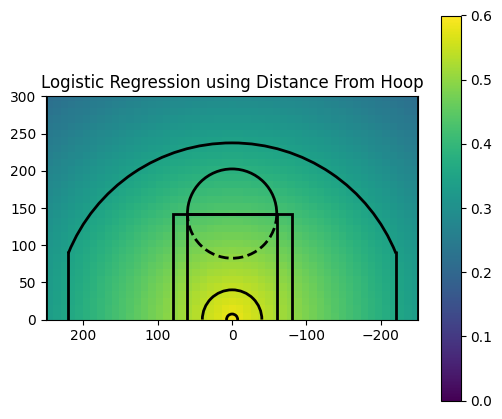

In [ ]:
#output_pred_xy = model_xy.predict_proba(sim_output[['X_SHOT_COORDINATE','Y_SHOT_COORDINATE']])
output_pred_dist = model_dist.predict_proba(sim_output[['L2_distance']])


output_pred_matrix = output_pred_dist[:,1].reshape(51,48).copy()

# Set the extent for the image
left = -250   # Left boundary
right = 250  # Right boundary
bottom = 0  # Bottom boundary
top = 470   # Top boundary


# plot all here
plt.figure(figsize=(6,5))
draw_court(outer_lines=True)
plt.imshow(output_pred_matrix.T, origin='lower', extent=(left, right, bottom, top), vmin=0, vmax=0.6)
# Descending values along the axis from left to right
plt.xlim(250,-250)
plt.ylim(0,300)
plt.colorbar()
plt.title('Logistic Regression using Distance From Hoop')
plt.show()

In [ ]:
# Let's look at the training set
total_shots_train = y_train.shape[0]
total_made_shots_train = y_train[y_train == 1].shape[0]
shot_avg_train = total_made_shots_train/total_shots_train

print("The training data stats ", total_shots_train, total_made_shots_train, shot_avg_train )

# Let's look at the test set
total_shots_test = y_test.shape[0]
total_made_shots_test = y_test[y_test == 1].shape[0]
shot_avg_test = total_made_shots_test/total_shots_test

print("The test data stats ", total_shots_test, total_made_shots_test, shot_avg_test )

The training data stats  13052 5832 0.4468280723260803
The test data stats  3264 1437 0.44025735294117646


In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.metrics import log_loss
from sklearn.metrics import mean_squared_error

# average shot
shot_avg = 0.4755
RMSE_train_avg_shot = np.sqrt(np.mean(np.square(shot_avg - y_train)))
shot_avg_list = np.ones((y_train.shape[0],1))*shot_avg
Brier_train_avg_shot = brier_score_loss(y_train, shot_avg_list )
Logloss_train_avg_shot = log_loss(y_train, shot_avg_list)


#logistic
logistic_train = model_dist.predict_proba(X_train['L2_distance'].values.reshape(-1, 1))
RMSE_train_logistic = np.sqrt(np.mean(np.square(logistic_train[:,1] - y_train)))
Brier_train_logistic = brier_score_loss(y_train, logistic_train[:,1] )
Logloss_train_logistic = log_loss(y_train, logistic_train[:,1])

print('RMSE_train_avg_shot: %0.4f, Logistic: %0.4f' %(RMSE_train_avg_shot, RMSE_train_logistic) )
print('Brier_train_avg_shot: %0.4f, Logistic: %0.4f' %(Brier_train_avg_shot, Brier_train_logistic) )
print('Logloss_train_avg_shot: %0.4f, Logistic: %0.4f' %(Logloss_train_avg_shot, Logloss_train_logistic) )


RMSE_train_avg_shot: 0.4980, Logistic: 0.4845
Brier_train_avg_shot: 0.2480, Logistic: 0.2348
Logloss_train_avg_shot: 0.6891, Logistic: 0.6622


In [ ]:
# average shot
shot_avg = 0.4755
RMSE_test_avg_shot = np.sqrt(np.mean(np.square(shot_avg - y_test)))
shot_avg_list = np.ones((y_test.shape[0],1))*shot_avg
Brier_test_avg_shot = brier_score_loss(y_test, shot_avg_list )
Logloss_test_avg_shot = log_loss(y_test, shot_avg_list)


#logistic
logistic_test = model_dist.predict_proba(X_test['L2_distance'].values.reshape(-1, 1))
RMSE_test_logistic = np.sqrt(np.mean(np.square(logistic_test[:,1] - y_test)))
Brier_test_logistic = brier_score_loss(y_test, logistic_test[:,1] )
Logloss_test_logistic = log_loss(y_test, logistic_test[:,1])

print('RMSE_test_avg_shot: %0.4f, Logistic: %0.4f' %(RMSE_test_avg_shot, RMSE_test_logistic) )
print('Brier_test_avg_shot: %0.4f,  Logistic: %0.4f' %(Brier_test_avg_shot, Brier_test_logistic) )
print('Logloss_test_avg_shot: %0.4f, Logistic: %0.4f' %(Logloss_test_avg_shot, Logloss_test_logistic) )


RMSE_test_avg_shot: 0.4977, Logistic: 0.4828
Brier_test_avg_shot: 0.2477,  Logistic: 0.2331
Logloss_test_avg_shot: 0.6885, Logistic: 0.6588


In [ ]:
from sklearn.ensemble import RandomForestClassifier

def learnRDF_plot(n_estimators):

  # Initialize and train a Random Forest Classifier with the specified number of estimators
  model_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=0)
  model_rf.fit(X_train['L2_distance'].values.reshape(-1, 1), y_train)

  output_pred_dist = model_rf.predict_proba(sim_output[['L2_distance']])


  output_pred_matrix = output_pred_dist[:,1].reshape(51,48).copy()

  # Set the extent for the image
  left = -250   # Left boundary
  right = 250  # Right boundary
  bottom = 0  # Bottom boundary
  top = 470   # Top boundary


  # plot all here
  plt.figure(figsize=(6,5))
  draw_court(outer_lines=True)
  plt.imshow(output_pred_matrix.T, origin='lower', extent=(left, right, bottom, top))
  # Descending values along the axis from left to right
  plt.xlim(250,-250)
  plt.ylim(0,300)
  plt.colorbar()
  title_name = 'The number of estimaors used was ' + str(n_estimators)
  plt.title(title_name)
  plt.show()


estimator_list = [1, 2, 5, 10, 20, 50, 100]

@interact(n_estimators=estimator_list)

def g(n_estimators):
    # we get these from the widgets
    learnRDF_plot(n_estimators)

interactive(children=(Dropdown(description='n_estimators', options=(1, 2, 5, 10, 20, 50, 100), value=1), Outpu…

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
shotDF['expected_prob'] = model_dist.predict_proba(shotDF['L2_distance'].values.reshape(-1, 1))[:, 1]
shotDF['expected_points'] = shotDF['expected_prob'] * shotDF['POINTS']
shotDF['actual_points'] = np.where(shotDF['EVENT_DESC'] == 'Field Goal Made', 1, 0) * shotDF['POINTS']

/tmp/ipython-input-682034124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shotDF['expected_prob'] = model_dist.predict_proba(shotDF['L2_distance'].values.reshape(-1, 1))[:, 1]
/tmp/ipython-input-682034124.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shotDF['expected_points'] = shotDF['expected_prob'] * shotDF['POINTS']
/tmp/ipython-input-682034124.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [ ]:
shotDF.head()

,GAME_CODE,SEASON,EVENT,EVENT_DESC,EVENT_DETAIL,DETAIL_DESC,SEQ,POINTS,OFF_TEAM_ID,OFFENSIVE_PLAYER,OFFENSIVE_PLAYER2,DEFENSIVE_PLAYER,PERIOD,TIME_REMAINING,SCORE_AFTER,SCORE_DEF_TEAM,DISTANCE,X_SHOT_COORDINATE,Y_SHOT_COORDINATE,FASTBREAK,IN_PAINT,SECOND_CHANCE,OFF_TURNOVER,L2_distance,expected_prob,expected_points,actual_points
2,2429380,2022,3,Field Goal Made,40.0,Layup Shot,6,2.0,153,850200.0,NaN,NaN,1,555.0,2,0,0.0,0.0,0.0,N,Y,N,Y,0.000000,0.584512,1.169024,2.0
6,2429380,2022,3,Field Goal Made,45.0,Jump Shot,14,3.0,151,336713.0,245628.0,NaN,1,496.0,3,5,27.0,11.1,24.8,N,N,N,N,27.170756,0.313719,0.941158,3.0
8,2429380,2022,4,Field Goal Missed,45.0,Jump Shot,18,3.0,151,408362.0,NaN,NaN,1,454.0,3,7,26.0,10.3,24.3,N,N,N,N,26.392802,0.320690,0.962070,0.0
9,2429380,2022,3,Field Goal Made,45.0,Jump Shot,20,2.0,153,923865.0,573744.0,NaN,1,442.0,9,3,19.0,-18.0,6.0,N,N,N,N,18.973666,0.390870,0.781740,2.0
11,2429380,2022,4,Field Goal Missed,45.0,Jump Shot,24,3.0,151,520283.0,NaN,NaN,1,403.0,3,9,27.0,-21.3,16.0,N,N,N,Y,26.640008,0.318466,0.955398,0.0


Question 5:
Current AI Assistants such as ChatGPT cannot fully answer these questions because they do not have direct access to specific datasets unless someone upload them. For example, the questions about team's home vs. away performance or shot charts require analyzing structured data files, but ChatGPT cannot generate correct answers without those inputs. Even when provided with data, the assistant may misinterpret column names, data structures, or the context of the assignment, since it cannot independently verify accuracy. AI assistants may produce convincing but incorrect outputs called hallucinations, such as creating results for statistics or models that were never calculated. This makes them useful for guidance and coding help, but not a reliable source for final answers without human oversight and validation.